# Customer Intelligence Platform

This notebook explores transactional e-commerce data to identify high-value customers, detect inactivity risk, and support customer retention decisions.

The analysis follows these steps:

1. Load and inspect the raw data  
2. Identify data quality issues  
3. Clean the dataset  
4. Create customer-level features  
5. Perform segmentation  
6. Analyze inactivity patterns  
7. Build a simple predictive model  
8. Create visualizations for reporting

## 1. Setup

This section imports the main libraries and defines the base project path.  
Using one base path makes it easier to load the dataset and save figures in a consistent way.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_PATH = Path().resolve().parent
BASE_PATH

WindowsPath('C:/Users/luker/Documents/customer_intelligence_platform')

## 2. Load the dataset

The Online Retail dataset contains transaction-level e-commerce data.  
Each row represents a purchased item within an invoice, and the data includes product information, quantities, prices, dates, and customer IDs.

In [2]:
file_path = BASE_PATH / "data/raw/Online Retail.xlsx"
df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Initial data inspection

Before cleaning the data, it is important to understand its basic structure.  
This includes the dataset size, column names, data types, and summary statistics.

In [3]:
df.shape

(541909, 8)

In [4]:
list(df.columns)

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 4. Data quality checks

The raw dataset is checked for issues that may affect customer-level analysis.  
The main checks focus on:

- missing customer IDs  
- product returns or refunds  
- the overall revenue distribution  
- the number of unique customers available for analysis

In [7]:
df["CustomerID"].isnull().sum()

np.int64(135080)

In [8]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [9]:
df["revenue"] = df["Quantity"] * df["UnitPrice"]
df["revenue"].describe()

count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: revenue, dtype: float64

In [10]:
df["CustomerID"].nunique()

4372

## 5. Interpretation of the raw data checks

The initial inspection revealed several important data quality issues.

- A substantial number of rows have missing `CustomerID` values, which makes customer-level analysis impossible for these transactions.
- Negative `Quantity` values indicate product returns or refunds.
- Revenue shows a highly skewed distribution, with a small number of transactions contributing very large values.
- The dataset contains enough unique customers for segmentation and predictive analysis.

Based on these findings, the cleaning step will:

- remove transactions with missing customer IDs  
- exclude returns or refunds  
- keep only transactions with positive prices

## 6. Data cleaning

In this step, the raw transactional data is cleaned so that only valid purchases remain.  
This creates a more reliable foundation for customer-level analysis.

In [11]:
df_clean = df[df["CustomerID"].notnull()]
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

df_clean["revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean.shape

(397884, 9)

In [12]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,revenue
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


## 7. Create order-level data

The original dataset is at item level, meaning that one invoice can appear in multiple rows.  
To make customer analysis easier, the data is first aggregated to one row per order.

In [13]:
df_orders = df_clean.groupby(["InvoiceNo", "CustomerID"]).agg({
    "InvoiceDate": "min",
    "revenue": "sum",
    "Quantity": "sum"
}).reset_index()

df_orders.head()

,InvoiceNo,CustomerID,InvoiceDate,revenue,Quantity
0,536365,17850.0,2010-12-01 08:26:00,139.12,40
1,536366,17850.0,2010-12-01 08:28:00,22.20,12
2,536367,13047.0,2010-12-01 08:34:00,278.73,83
3,536368,13047.0,2010-12-01 08:34:00,70.05,15
4,536369,13047.0,2010-12-01 08:35:00,17.85,3


## 8. Create customer-level features

Next, the order-level data is aggregated to customer level.  
This allows us to calculate features that describe customer behavior, such as:

- total number of orders  
- total revenue  
- recency  
- average order value

In [14]:
snapshot_date = df_orders["InvoiceDate"].max()

customer_df = df_orders.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "revenue": "sum",
    "InvoiceDate": "max"
}).reset_index()

customer_df.rename(columns={
    "InvoiceNo": "total_orders",
    "revenue": "total_revenue",
    "InvoiceDate": "last_purchase_date"
}, inplace=True)

customer_df["recency"] = (snapshot_date - customer_df["last_purchase_date"]).dt.days
customer_df["avg_order_value"] = customer_df["total_revenue"] / customer_df["total_orders"]
customer_df["CustomerID"] = customer_df["CustomerID"].astype(int)

customer_df.head()

,CustomerID,total_orders,total_revenue,last_purchase_date,recency,avg_order_value
0,12346,1,77183.60,2011-01-18 10:01:00,325,77183.600000
1,12347,7,4310.00,2011-12-07 15:52:00,1,615.714286
2,12348,4,1797.24,2011-09-25 13:13:00,74,449.310000
3,12349,1,1757.55,2011-11-21 09:51:00,18,1757.550000
4,12350,1,334.40,2011-02-02 16:01:00,309,334.400000


In [15]:
customer_df.describe()

,CustomerID,total_orders,total_revenue,last_purchase_date,recency,avg_order_value
count,4338.000000,4338.000000,4338.000000,4338,4338.000000,4338.000000
mean,15300.408022,4.272015,2054.266460,2011-09-08 11:38:58.990318336,91.536422,419.166289
min,12346.000000,1.000000,3.750000,2010-12-01 09:53:00,0.000000,3.450000
25%,13813.250000,1.000000,307.415000,2011-07-20 19:18:00,17.000000,178.625000
50%,15299.500000,2.000000,674.485000,2011-10-20 10:40:30,50.000000,293.900000
75%,16778.750000,5.000000,1661.740000,2011-11-22 11:05:45,141.000000,430.113750
max,18287.000000,209.000000,280206.020000,2011-12-09 12:50:00,373.000000,84236.250000
std,1721.808492,7.697998,8989.230441,NaN,100.014169,1796.537944


## 9. RFM scoring

RFM stands for:

- **Recency**: how recently a customer purchased  
- **Frequency**: how often a customer purchased  
- **Monetary**: how much a customer spent  

These scores are used to create simple customer segments.

In [16]:
customer_df["R_score"] = pd.qcut(customer_df["recency"], 4, labels=[4, 3, 2, 1])
customer_df["F_score"] = pd.qcut(customer_df["total_orders"].rank(method="first"), 4, labels=[1, 2, 3, 4])
customer_df["M_score"] = pd.qcut(customer_df["total_revenue"], 4, labels=[1, 2, 3, 4])

customer_df["RFM_score"] = (
    customer_df["R_score"].astype(str) +
    customer_df["F_score"].astype(str) +
    customer_df["M_score"].astype(str)
)

customer_df.head()

,CustomerID,total_orders,total_revenue,last_purchase_date,recency,avg_order_value,R_score,F_score,M_score,RFM_score
0,12346,1,77183.60,2011-01-18 10:01:00,325,77183.600000,1,1,4,114
1,12347,7,4310.00,2011-12-07 15:52:00,1,615.714286,4,4,4,444
2,12348,4,1797.24,2011-09-25 13:13:00,74,449.310000,2,3,4,234
3,12349,1,1757.55,2011-11-21 09:51:00,18,1757.550000,3,1,4,314
4,12350,1,334.40,2011-02-02 16:01:00,309,334.400000,1,1,2,112


## 10. Customer segmentation

A simple rule-based segmentation approach is used to create four groups:

- **Champions**  
- **Loyal Customers**  
- **At Risk**  
- **Others**  

This makes the results easier to interpret from a business perspective.

In [17]:
def segment_customer(row):
    if row["R_score"] == 4 and row["F_score"] == 4:
        return "Champions"
    elif row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "At Risk"
    else:
        return "Others"

customer_df["segment"] = customer_df.apply(segment_customer, axis=1)

customer_df["segment"].value_counts()

segment
Loyal Customers    1560
At Risk            1504
Others              665
Champions           609
Name: count, dtype: int64

In [18]:
customer_df.groupby("segment")["total_revenue"].sum().sort_values(ascending=False)

segment
Champions          4578426.310
Loyal Customers    3063881.532
At Risk             767146.842
Others              501953.220
Name: total_revenue, dtype: float64

In [19]:
customer_df.groupby("segment")["total_revenue"].mean().sort_values(ascending=False)

segment
Champions          7517.941396
Loyal Customers    1964.026623
Others              754.816872
At Risk             510.071039
Name: total_revenue, dtype: float64

A small segment of customers (**Champions**) generates a disproportionately large share of revenue, while a large group of customers is classified as **At Risk**.  
This already suggests that not all customers should be treated equally: some groups are much more important for retention than others.

## 11. Inactivity analysis

To create a simple proxy for churn, a customer is considered **inactive** if their recency is greater than 90 days.  
This is a practical inactivity definition for this project.

In [20]:
threshold = 90
customer_df["is_inactive"] = (customer_df["recency"] > threshold).astype(int)

customer_df["is_inactive"].value_counts()

is_inactive
0    2893
1    1445
Name: count, dtype: int64

In [21]:
pd.crosstab(customer_df["segment"], customer_df["is_inactive"])

is_inactive,0,1
segment,,
At Risk,410,1094
Champions,609,0
Loyal Customers,1209,351
Others,665,0


The RFM segmentation aligns well with actual inactivity behavior.  
A large part of the **At Risk** segment is inactive, while **Champions** remain active.  
This suggests that the segmentation is useful for identifying customers who may need retention actions.

## 12. Revenue impact of inactivity

The next step is to examine how much revenue is connected to inactive customers.  
This helps move from descriptive analysis to business impact.

In [22]:
customer_df.groupby("is_inactive")["total_revenue"].sum()

is_inactive
0    7878043.823
1    1033364.081
Name: total_revenue, dtype: float64

In [23]:
customer_df.groupby(["segment", "is_inactive"])["total_revenue"].sum()

segment          is_inactive
At Risk          0               232521.641
                 1               534625.201
Champions        0              4578426.310
Loyal Customers  0              2565142.652
                 1               498738.880
Others           0               501953.220
Name: total_revenue, dtype: float64

While high-value customers (**Champions**) remain active, a substantial part of revenue is linked to customers who are already inactive or at risk of inactivity.  
This means that inactivity is not only a behavioral issue, but also a financial problem.

## 13. Priority segmentation

To make the analysis more actionable, customers are grouped into business priority labels based on their segment and inactivity status.

In [24]:
def priority_segment(row):
    if row["segment"] == "Champions":
        return "Protect"
    elif row["segment"] == "Loyal Customers" and row["is_inactive"] == 1:
        return "Re-engage High Value"
    elif row["segment"] == "At Risk" and row["is_inactive"] == 1:
        return "Urgent Recovery"
    elif row["segment"] == "At Risk":
        return "Monitor"
    else:
        return "Low Priority"

customer_df["priority"] = customer_df.apply(priority_segment, axis=1)

customer_df["priority"].value_counts()

priority
Low Priority            1874
Urgent Recovery         1094
Protect                  609
Monitor                  410
Re-engage High Value     351
Name: count, dtype: int64

## Priority Segmentation and Business Interpretation

To translate the analytical results into actionable business decisions, customers were grouped into priority segments based on their value and inactivity status.

### Priority Segment Definitions

- **Protect**  
  High-value customers (Champions) who are still active.  
  These customers generate the most revenue and should be retained carefully.

- **Re-engage High Value**  
  Loyal customers who have become inactive.  
  These customers were valuable in the past and may still be recoverable.

- **Urgent Recovery**  
  At-risk customers who are already inactive.  
  This group represents immediate revenue loss and should be treated as a high-priority retention group.

- **Monitor**  
  At-risk customers who are still active.  
  These customers show warning signs and should be watched closely.

- **Low Priority**  
  Customers with lower value or lower urgency.  
  These customers have less impact on overall revenue.

### Main conclusion

Instead of treating all customers the same, this approach helps identify which customers should receive the most attention in retention efforts.

## 14. Predictive modeling

A simple logistic regression model is used to predict inactivity.  
The goal is not to build the most complex model, but to create an interpretable baseline.

### First modeling attempt and leakage issue

At first, the model included `recency` as a feature.  
However, this caused data leakage because the target variable `is_inactive` was directly defined from recency.

For that reason, recency must be removed from the final feature set.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X = customer_df[[
    "total_orders",
    "total_revenue",
    "avg_order_value"
]]

y = customer_df["is_inactive"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       561
           1       0.60      0.55      0.58       307

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868

ROC-AUC: 0.7650310346229104


After removing the recency feature, the model achieved a more realistic performance.  
This is important because it shows that the model still captures meaningful behavior patterns without relying on leakage.

The result should be interpreted as a simple and explainable baseline, not as a final production model.

## 15. Visualizations

The following charts summarize the most important customer insights and are also saved to the `outputs/figures` folder for use in the README or a dashboard.

In [26]:
(BASE_PATH / "outputs/figures").mkdir(parents=True, exist_ok=True)

segment_order = ["Champions", "Loyal Customers", "At Risk", "Others"]

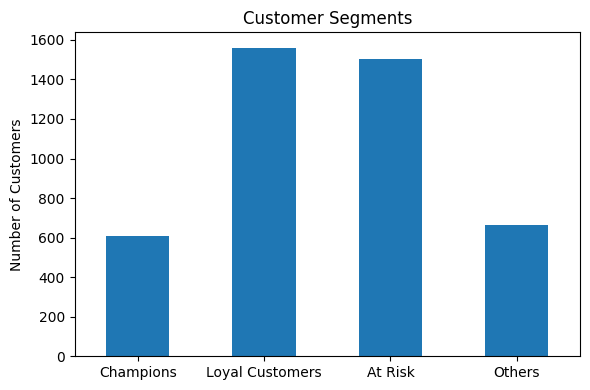

In [27]:
counts = customer_df["segment"].value_counts().reindex(segment_order)

plt.figure(figsize=(6, 4))
counts.plot(kind="bar")
plt.title("Customer Segments")
plt.xlabel("")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_PATH / "outputs/figures/segment_distribution.png")
plt.show()

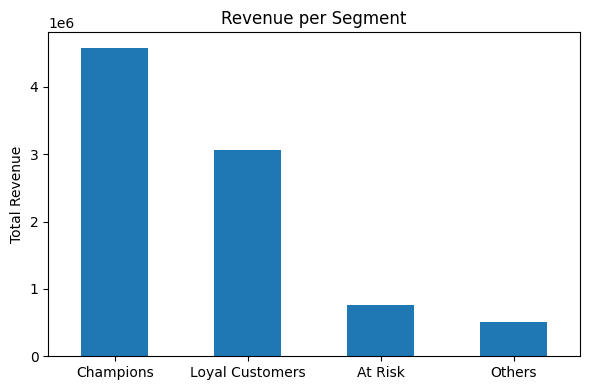

In [28]:
revenue = customer_df.groupby("segment")["total_revenue"].sum().reindex(segment_order)

plt.figure(figsize=(6, 4))
revenue.plot(kind="bar")
plt.title("Revenue per Segment")
plt.xlabel("")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE_PATH / "outputs/figures/revenue_per_segment.png")
plt.show()

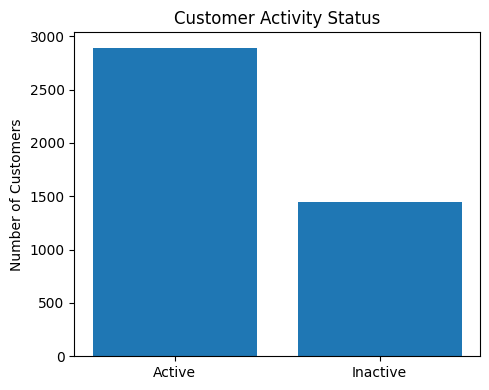

In [29]:
labels = ["Active", "Inactive"]
values = customer_df["is_inactive"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(labels, values)
plt.title("Customer Activity Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(BASE_PATH / "outputs/figures/inactive_vs_active.png")
plt.show()

## 16. Final conclusion

This notebook showed how transactional e-commerce data can be transformed into customer-level insights.

The main findings are:

- a small group of customers generates a large share of total revenue  
- a meaningful share of customers is inactive or at risk  
- combining segmentation and inactivity creates more useful business decisions than looking at churn alone  
- a simple logistic regression model provides a reasonable baseline for predicting inactivity  

Overall, this project demonstrates a Python-based customer analytics workflow that connects data cleaning, feature engineering, segmentation, predictive modeling, and business interpretation.

In [30]:
from pathlib import Path

BASE_PATH = Path().resolve().parent

(BASE_PATH / "data/processed").mkdir(parents=True, exist_ok=True)

customer_df.to_csv(BASE_PATH / "data/processed/customer_features.csv", index=False)